In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
import joblib

from src import flatten_journeys, create_journey_features

## Generate Training Data

In [2]:
# Create flattened training data
flatten_journeys('data/dat_train2.csv', 'train_data2_flattened')

Flattening journeys
-------------------
Successfully read in file.
Dropped duplicate entries and corrected values for journey steps until end.
Created a single entry for each journey.
Successfully created parquet file.


In [2]:
df = pd.read_parquet("data/train_data2_flattened.parquet")

In [3]:
df.head()

,id,events,event_names,timestamps,journey_length
0,-1000001271 551641434,"[12, 4, 19, 19, 19, 2, 4]","[application_web_approved, browse_products, ap...","[2022-10-31T13:45:59.000000, 2022-10-31T13:47:...",7
1,-100000293 92584960,"[12, 4, 4, 4, 4, 4, 4, 4, 11, 4, 4, 11, 4, 11,...","[application_web_approved, browse_products, br...","[2021-11-11T01:30:43.000000, 2021-11-11T01:39:...",31
2,-100001025 -1674572031,"[2, 19, 1, 19, 19, 19, 19, 19, 19, 19, 3, 19, ...","[campaign_click, application_web_view, promoti...","[2022-05-09T06:00:00.000000, 2022-05-09T13:10:...",26
3,-1000011207 -1448136887,"[12, 4, 11, 5, 5, 5, 4, 5, 4, 4, 4, 4, 1, 4, 4...","[application_web_approved, browse_products, ad...","[2021-03-21T11:19:48.000000, 2021-03-21T11:27:...",61
4,-100001164 -1710062169,[15],[application_phone_approved],[2022-12-02T07:45:16.000000],1


In [5]:
min_timestamp = np.datetime64('2026-01-01T00:00:00')
max_timestamp = np.datetime64('2000-01-01T00:00:00')

for row in df.itertuples(index=False):
    if row.timestamps[0] < min_timestamp:
        min_timestamp = row.timestamps[0]
    if row.timestamps[-1] > max_timestamp:
        max_timestamp = row.timestamps[-1]

In [23]:
print(f"Earliest timestamp is {min_timestamp}")
print(f"Latest timestamp is {max_timestamp}")

Earliest timestamp is 2020-11-03T03:31:30.000000
Latest timestamp is 2023-05-23T12:29:50.000000


In [4]:
start_timestamp = pd.Timestamp('2020-11-03 03:31:30+0000', tz='UTC')
end_timestamp = pd.Timestamp('2023-05-23 12:29:50+0000', tz='UTC')

We have 4 more months worth of data than before.

In [5]:
outcomes = []
for row in df.itertuples(index=False):
    if 28 in row.events:
        outcomes.append('successful')
    elif (end_timestamp - pd.Timestamp(row.timestamps[-1], tz='UTC')) / np.timedelta64(1, 'D') > 60:
        outcomes.append('unsuccessful')
    else:
        outcomes.append('ongoing')

df['outcome'] = outcomes

In [6]:
first_timestamps = []
last_timestamps = []

for row in df.itertuples(index=False):
    first_timestamps.append(pd.Timestamp(row.timestamps[0], tz='UTC'))
    if row.outcome == 'successful':
        last_timestamps.append(pd.Timestamp(row.timestamps[np.where(row.events == 28)[0][0]], tz='UTC'))
    elif row.outcome == 'unsuccessful':
        last_timestamps.append(pd.Timestamp(row.timestamps[-1] + np.timedelta64(60, 'D'), tz='UTC'))
    else:
        last_timestamps.append(end_timestamp)

df['start_date'] = first_timestamps
df['end_timestamp'] = last_timestamps

In [7]:
training_dataset = df[df['outcome'] != 'ongoing'].copy()
test_dataset = df[df['outcome'] == 'ongoing'].copy()

In [8]:
train_df, val_df = train_test_split(training_dataset, test_size=0.3, random_state=0)

In [9]:
np.random.seed(823)

# We have about 31 months worth of data and want a cutoff about once every 2 weeks (on average)
time_splits = start_timestamp + (end_timestamp - start_timestamp) * np.random.random(size=62)

sampled_journeys_train = []
sampled_journeys_val = []

# We want about 4.5 million journeys from our 62 time splits => want about 75,000 journeys per time split
for split in time_splits:
    ongoing_journeys_train = train_df[(train_df['start_date'] < split) & (train_df['end_timestamp'] > split)]
    ongoing_journeys_train = ongoing_journeys_train.sample(n=min(ongoing_journeys_train.shape[0], 75000))
    ongoing_journeys_train['current_datetime'] = split
    sampled_journeys_train.append(ongoing_journeys_train)

    ongoing_journeys_val = val_df[(val_df['start_date'] < split) & (val_df['end_timestamp'] > split)]
    ongoing_journeys_val = ongoing_journeys_val.sample(n=min(ongoing_journeys_val.shape[0], 40000))
    ongoing_journeys_val['current_datetime'] = split
    sampled_journeys_val.append(ongoing_journeys_val)

sampled_train_df = pd.concat(sampled_journeys_train, ignore_index=True)
sampled_val_df = pd.concat(sampled_journeys_val, ignore_index=False)

In [10]:
sampled_train_df.reset_index(drop=True, inplace=True)
sampled_val_df.reset_index(drop=True, inplace=True)

In [11]:
# Update columns in datasets so that they reflect the journey up until the cutoff time
def truncate_journeys(df):
    for i in range(len(df)):
        timestamps = df.at[i, 'timestamps']
        cutoff_time = df.at[i, 'current_datetime'].tz_localize(None)

        cutoff_index = np.searchsorted(timestamps, cutoff_time, side='right')

        df.at[i, 'timestamps'] = timestamps[:cutoff_index]
        df.at[i, 'events'] = df.at[i, 'events'][:cutoff_index]
        df.at[i, 'event_names'] = df.at[i, 'event_names'][:cutoff_index]
        df.at[i, 'journey_length'] = cutoff_index

truncate_journeys(sampled_train_df)
truncate_journeys(sampled_val_df)

In [12]:
# This gives us about 4 million journeys for training and 2 million for validation, which seems sufficient for now
print(f"There are {sampled_train_df.shape[0]} training journeys and {sampled_val_df.shape[0]} validation journeys")

There are 4120543 training journeys and 2143804 validation journeys


In [13]:
# Shuffle rows so that splits from the same journey are not grouped together
sampled_train_df = sampled_train_df.sample(frac=1, random_state=523).reset_index(drop=True)
sampled_val_df = sampled_val_df.sample(frac=1, random_state=784).reset_index(drop=True)

In [14]:
test_dataset['current_datetime'] = end_timestamp

In [15]:
def normalize_list_column(col):
    def normalize(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return []                 # empty list, not NaN
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, list):
            return x
        return [x]                    # scalar → list
    return col.apply(normalize)

In [16]:
sampled_train_df['events'] = normalize_list_column(sampled_train_df['events'])
sampled_val_df['events']   = normalize_list_column(sampled_val_df['events'])
sampled_train_df['timestamps'] = normalize_list_column(sampled_train_df['timestamps'])
sampled_val_df['timestamps']   = normalize_list_column(sampled_val_df['timestamps'])
sampled_train_df['event_names'] = normalize_list_column(sampled_train_df['event_names'])
sampled_val_df['event_names']   = normalize_list_column(sampled_val_df['event_names'])

In [17]:
def normalize_for_parquet(df: pd.DataFrame) -> pd.DataFrame:
    """
    Robustly standardizes list columns for Parquet.
    Handles None, NaNs, scalars, and crucially, converts numpy arrays to lists.
    """
    def robust_ensure_list(x):
        if x is None: 
            return []
        # Handle NaN (float)
        if isinstance(x, float) and np.isnan(x): 
            return []
        # FIX: Convert numpy array to list
        if isinstance(x, np.ndarray): 
            return x.tolist()
        # List stays list
        if isinstance(x, list): 
            return x
        # Scalar becomes list
        return [x]

    def clean_str_list(lst):
        # Convert all elements to strings to avoid PyArrow mixed-type errors
        return [str(x) for x in lst] if lst else []

    # 1. Normalize structure (ensure everything is a list)
    for col in ["events", "event_names", "timestamps"]:
        if col in df.columns:
            df[col] = df[col].apply(robust_ensure_list)

    # 2. Enforce string types for event_names (common source of Arrow errors)
    if "event_names" in df.columns:
        df["event_names"] = df["event_names"].apply(clean_str_list)
        
    # 3. Ensure events are compatible (optional, usually ints are fine in lists)
    # If you have mixed types in 'events', uncomment the line below:
    # if "events" in df.columns: df["events"] = df["events"].apply(clean_str_list)

    return df

# Apply the fix
sampled_train_df = normalize_for_parquet(sampled_train_df)
sampled_val_df   = normalize_for_parquet(sampled_val_df)
test_dataset     = normalize_for_parquet(test_dataset)

# Save
sampled_train_df.to_parquet("data/training_data2.parquet", index=False)
sampled_val_df.to_parquet("data/validation_data2.parquet", index=False)
test_dataset.to_parquet("data/testing_data2.parquet", index=False)

print("✅ Data normalized and saved successfully.")

✅ Data normalized and saved successfully.


## Training XGBoost Model

In [1]:
import pandas as pd

In [ ]:
df = pd.read_parquet("data/training_data2.parquet")

In [10]:
df.head()

,id,events,event_names,timestamps,journey_length,outcome,start_date,end_timestamp,current_datetime,days_since_last_valid_event
0,-674722267 798539662,"[19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 3, 19...","[application_web_view, application_web_view, a...","[2022-09-12T21:54:14.000000, 2022-09-12T21:54:...",38,unsuccessful,2022-09-12 21:54:14+00:00,2023-01-24 14:04:26+00:00,2023-01-17 00:33:38+00:00,52.436943
1,1319465230 1017340569,"[12, 4, 11, 5, 6, 5, 1, 2, 1, 1, 21, 1, 1, 1]","[application_web_approved, browse_products, ad...","[2021-06-28T02:17:43.000000, 2021-06-28T02:18:...",14,unsuccessful,2021-06-28 02:17:43+00:00,2022-06-11 12:18:56+00:00,2021-11-11 21:13:10+00:00,136.634140
2,-1918371518 1364932167,"[21, 15, 24, 24, 24]","[catalog_(mail), application_phone_approved, c...","[2022-12-22T00:00:00.000000, 2023-01-17T12:45:...",5,unsuccessful,2022-12-22 00:00:00+00:00,2023-05-15 16:07:14+00:00,2023-04-23 04:12:40+00:00,37.503773
3,1777788671 1527064699,"[2, 19, 19, 19, 3, 19, 19, 19, 3, 19, 19, 3, 1...","[campaign_click, application_web_view, applica...","[2021-01-11T06:00:00.000000, 2021-01-11T12:31:...",56,unsuccessful,2021-01-11 06:00:00+00:00,2021-11-15 01:43:03+00:00,2021-10-13 11:24:11+00:00,168.888977
4,-878528552 366162042,"[2, 12, 29, 4, 4, 4, 11, 4, 11, 4, 11, 5, 6, 5...","[campaign_click, application_web_approved, acc...","[2021-02-27T06:00:00.000000, 2021-02-27T10:09:...",20,unsuccessful,2021-02-27 06:00:00+00:00,2021-12-05 19:57:02+00:00,2021-03-25 06:48:18+00:00,19.454502


In [5]:
create_journey_features("data/training_data2.parquet", "training_data2_features")

Creating Features for data
--------------------------
Successfully read in files.
Added date and previous journey information.
Added number of days since the journey began.
Added last event in journey
Added number of days since last event.
Added days since last user action
Added quantiles for the number of days between actions in the journey.
Added first event id in journey.
Added number of occurrences for repeatable events.
Added indicator for whether each milestone was reached.
Added the number of days until each milestone was achieved during the journey.
Successfully created parquet file.


In [15]:
create_journey_features("data/validation_data2.parquet", "validation_data2_features")

Creating Features for data
--------------------------
Successfully read in files.
Added date and previous journey information.
Added number of days since the journey began.
Added last event in journey
Added number of days since last event.
Added days since last user action
Added quantiles for the number of days between actions in the journey.
Added first event id in journey.
Added number of occurrences for repeatable events.
Added indicator for whether each milestone was reached.
Added the number of days until each milestone was achieved during the journey.
Successfully created parquet file.


In [16]:
train_df = pd.read_parquet('data/training_data2_features.parquet')
val_df = pd.read_parquet('data/validation_data2_features.parquet')

In [17]:
X_train = train_df.drop(columns=['id', 'events', 'event_names', 'timestamps', 'outcome', 'start_date', 'end_timestamp', 'current_datetime', 'customer_id'])
y_train = (train_df["outcome"] == 'successful').astype('int')

X_val = val_df.drop(columns=['id', 'events', 'event_names', 'timestamps', 'outcome', 'start_date', 'end_timestamp', 'current_datetime', 'customer_id'])
y_val = (val_df["outcome"] == 'successful').astype('int')

# For now, also drop days_to_milestone columns
milestone_days=r"^days_to_milestone_"
X_train = X_train.drop(columns=X_train.columns[X_train.columns.str.contains(milestone_days, regex=True)])
X_val = X_val.drop(columns=X_val.columns[X_val.columns.str.contains(milestone_days, regex=True)])

In [18]:
# Impute quantiles with the length of the journey (in days)
cols = X_train.filter(
    regex=r"^days_between_actions_q_"
).columns

X_train_sub = X_train[cols]
X_train.loc[:, cols] = X_train_sub.where(
    X_train_sub.notna(),
    X_train["days_into_journey"],
    axis=0
)

X_val_sub = X_val[cols]
X_val.loc[:, cols] = X_val_sub.where(
    X_val_sub.notna(),
    X_val["days_into_journey"],
    axis=0
)

In [19]:
# First train using old hyperparameters from previous model
xgboost_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=50,
    colsample_bytree=0.8,
    max_depth=10,
    subsample=1.0,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=642
)

xgboost_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

`{'n_estimators': 50, 'colsample_bytree': 0.8, 'max_depth': 10, 'subsample': 1.0}`

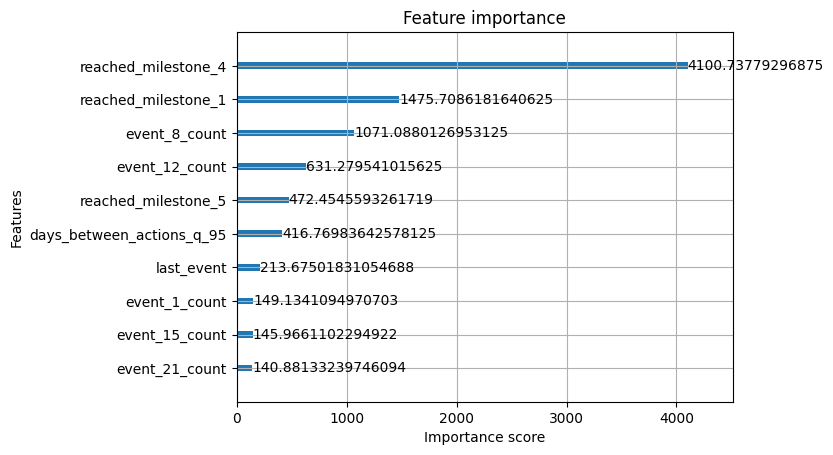

In [20]:
from xgboost import plot_importance

plot_importance(xgboost_model, importance_type="gain", max_num_features=10)
plt.show()

In [21]:
from sklearn.metrics import classification_report

val_preds = xgboost_model.predict(X_val)
print("\nValidation Set Performance:")
print(classification_report(y_val, val_preds))


Validation Set Performance:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97   2017614
           1       0.81      0.09      0.16    126190

    accuracy                           0.95   2143804
   macro avg       0.88      0.54      0.57   2143804
weighted avg       0.94      0.95      0.92   2143804



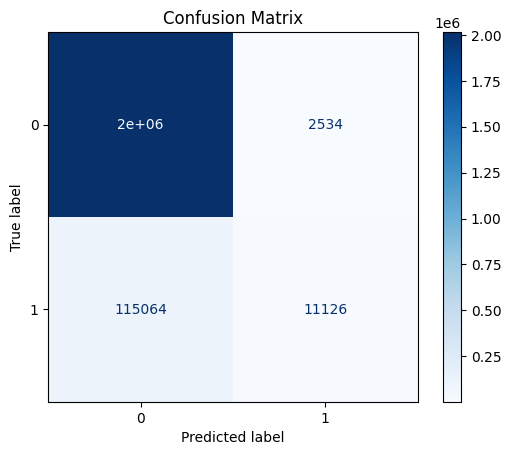

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get predictions from your model (or GridSearchCV object)
y_pred = xgboost_model.predict(X_val)

# 2. Generate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgboost_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [23]:
val_preds_prob = xgboost_model.predict_proba(X_val)[:, 1]
print(f"Brier loss on Random Forest model is {brier_score_loss(y_val, val_preds_prob)}")

Brier loss on Random Forest model is 0.04851237311959267


In [24]:
joblib.dump(xgboost_model, 'models/xgboost_model2_old_params.joblib')

['models/xgboost_model2_old_params.joblib']

Now let's do a hyperparameter sweep to determine the best parameters.

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import brier_score_loss, make_scorer

brier_scorer = make_scorer(
    brier_score_loss,
    response_method="predict_proba",
    greater_is_better=False
)

param_grid = {
    "n_estimators": [50],
    "max_depth": [12],
    "subsample": [1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1]
}

xgboost_model = XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=642
)

clf = GridSearchCV(
    estimator=xgboost_model,
    param_grid=param_grid,
    scoring=brier_scorer,
    cv=3,
    n_jobs=5
)

clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'max_depth': [12], 'n_estimators': [50], 'subsample': [1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(b...redict_proba')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [27]:
clf.best_params_

{'colsample_bytree': 1, 'max_depth': 12, 'n_estimators': 50, 'subsample': 1.0}

In [28]:
best_model = clf.best_estimator_

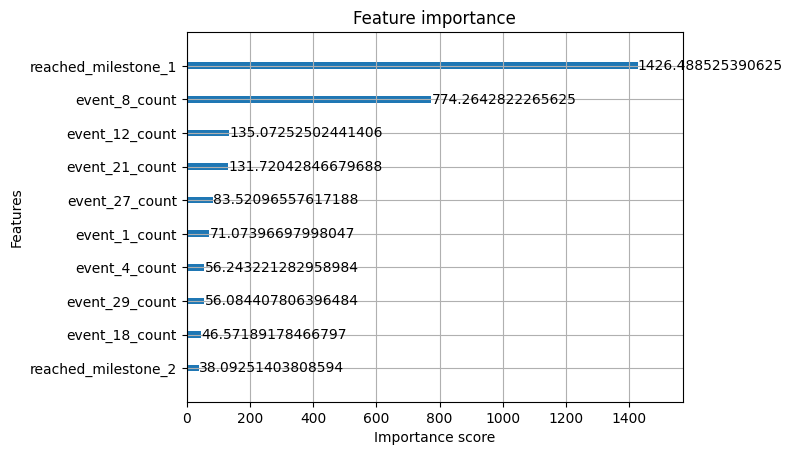

In [29]:
from xgboost import plot_importance

plot_importance(best_model, importance_type="gain", max_num_features=10)
plt.show()

In [30]:
from sklearn.metrics import classification_report

val_preds = best_model.predict(X_val)
print("\nValidation Set Performance:")
print(classification_report(y_val, val_preds))


Validation Set Performance:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97   2017614
           1       0.69      0.06      0.11    126190

    accuracy                           0.94   2143804
   macro avg       0.82      0.53      0.54   2143804
weighted avg       0.93      0.94      0.92   2143804



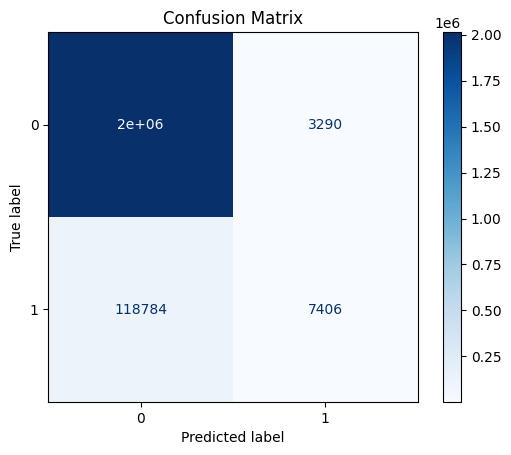

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get predictions from your model (or GridSearchCV object)
y_pred = best_model.predict(X_val)

# 2. Generate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [32]:
val_preds_prob = best_model.predict_proba(X_val)[:, 1]
print(f"Brier loss on Random Forest model is {brier_score_loss(y_val, val_preds_prob)}")

Brier loss on Random Forest model is 0.050502270460128784


In [40]:
joblib.dump(best_model, 'models/xgboost_model2_tuned_params.joblib')

['models/xgboost_model2_tuned_params.joblib']

## Make Predictions on Test Data

In [6]:
# Create flattened test data
flatten_journeys('data/open_journeys2.csv', 'test_data2_flattened')

Flattening journeys
-------------------
Successfully read in file.
Dropped duplicate entries and corrected values for journey steps until end.
Created a single entry for each journey.
Successfully created parquet file.


In [25]:
# Create test data features
create_journey_features("data/test_data2_flattened.parquet", "test_data2_features")

Creating Features for data
--------------------------
Successfully read in files.
Added date and previous journey information.
Added number of days since the journey began.
Added last event in journey
Added number of days since last event.
Added days since last user action
Added quantiles for the number of days between actions in the journey.
Added first event id in journey.
Added number of occurrences for repeatable events.
Added indicator for whether each milestone was reached.
Added the number of days until each milestone was achieved during the journey.
Successfully created parquet file.


In [26]:
test_df = pd.read_parquet("data/test_data2_features.parquet") 

In [27]:
X_test = test_df.drop(columns=['id', 'customer_id', 'events', 'event_names', 'timestamps', 'start_date', 'end_timestamp', 'current_datetime', 'customer_id'])
milestone_days=r"^days_to_milestone_"
X_test = X_test.drop(columns=X_test.columns[X_test.columns.str.contains(milestone_days, regex=True)])

In [28]:
cols = X_test.filter(
    regex=r"^days_between_actions_q_"
).columns

X_test_sub = X_test[cols]
X_test.loc[:, cols] = X_test_sub.where(
    X_test_sub.notna(),
    X_test["days_into_journey"],
    axis=0
)

In [29]:
best_model = joblib.load('models/xgboost_model2_old_params.joblib')
test_predictions = best_model.predict_proba(X_test)[:, 1]

In [30]:
test_output = pd.DataFrame({
    'id': test_df['id'],
    'order_shipped': test_predictions
})

In [31]:
test_output.to_csv("data/xgboost_model2_old_predictions.csv", index=False)